In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
import os
import librosa
from tqdm import tqdm

# What is the mean duration (in seconds) of the Jazz genre stems in train (genres_stems) dataset?

In [5]:
DATA_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/jazz"

dur_list = []

for song in tqdm(os.listdir(DATA_PATH)):
    song_path = os.path.join(DATA_PATH, song)

    for audio in os.listdir(song_path):
        audio_path = os.path.join(song_path, audio)

        audio, sr = librosa.load(audio_path, sr=None)
        duration = len(audio)/sr
        dur_list.append(duration)

print("Mean duration (in seconds) of the Jazz genre stems in train (genres_stems) dataset:", np.mean(dur_list))

100%|██████████| 100/100 [00:53<00:00,  1.88it/s]

Mean duration (in seconds) of the Jazz genre stems in train (genres_stems) dataset: 30.032979591836728


# What are the unique sample rates present in the entire dataset? (consider genre stems, noise data and mashups)

Enter your answer as a comma separated list. Example: [40000, 50000, 60000]

In [6]:
# Noise data

DATA_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio"

noise_sr = []

for song in tqdm(os.listdir(DATA_PATH)):
    audio_path = os.path.join(DATA_PATH, song)

    audio, sr = librosa.load(audio_path, sr=None)
    noise_sr.append(sr)

print("Unique sample rates present in noise data:", set(noise_sr))

100%|██████████| 2000/2000 [00:23<00:00, 83.75it/s]

Unique sample rates present in noise data: {44100}


In [7]:
# Train data

DATA_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"
GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
STEMS = ['bass.wav', 'drums.wav', 'other.wav', 'vocals.wav']

train_srs = []

for genre in GENRES:
    print("Processing", genre, ".......")
    genre_path = os.path.join(DATA_PATH, genre)
    
    for song in tqdm(os.listdir(genre_path)):
        song_path = os.path.join(genre_path, song)

        for stem in STEMS:
            audio_path = os.path.join(song_path, stem)

            y, sr = librosa.load(audio_path, sr=None)
            
            train_srs.append(sr)

print("Unique sample rates present in Train data:", set(train_srs))

Processing blues .......


100%|██████████| 100/100 [00:36<00:00,  2.71it/s]


Processing classical .......


100%|██████████| 100/100 [00:32<00:00,  3.03it/s]


Processing country .......


...

Processing reggae .......


100%|██████████| 100/100 [00:38<00:00,  2.62it/s]


Processing rock .......


100%|██████████| 100/100 [00:40<00:00,  2.48it/s]

Unique sample rates present in Train data: {44100}


In [8]:
# Test(Mashups) data

DATA_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/mashups"

test_sr = []

for song in tqdm(os.listdir(DATA_PATH)):
    audio_path = os.path.join(DATA_PATH, song)

    audio, sr = librosa.load(audio_path, sr=None)
    test_sr.append(sr)

print("Unique sample rates present in test data:", set(test_sr))

100%|██████████| 3020/3020 [01:02<00:00, 48.25it/s]

Unique sample rates present in test data: {22050}


# How many empty or zero-byte audio files are present in the train dataset?

In [9]:
DATA_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"
GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
STEMS = ['bass.wav', 'drums.wav', 'other.wav', 'vocals.wav']

empty_files = []

for genre in GENRES:
    print("Processing", genre, ".......")
    genre_path = os.path.join(DATA_PATH, genre)
    
    for song in tqdm(os.listdir(genre_path)):
        song_path = os.path.join(genre_path, song)

        for stem in STEMS:
            audio_path = os.path.join(song_path, stem)
            
            if os.path.getsize(audio_path) == 0:
                empty_files.append(audio_path)

print("Empty or zero-byte audio files present in the train dataset:", len(empty_files))

Processing blues .......


100%|██████████| 100/100 [00:00<00:00, 286.49it/s]


Processing classical .......


100%|██████████| 100/100 [00:00<00:00, 300.64it/s]


Processing country .......


...

Processing reggae .......


100%|██████████| 100/100 [00:00<00:00, 297.50it/s]


Processing rock .......


100%|██████████| 100/100 [00:00<00:00, 255.97it/s]

Empty or zero-byte audio files present in the train dataset: 0


# What is the average peak amplitude (in dB) for vocal stems in train dataset?

In [10]:
DATA_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"
GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
STEM = 'vocals.wav'

peak_db_values = []

for genre in GENRES:
    print("Processing", genre, ".......")
    genre_path = os.path.join(DATA_PATH, genre)
    
    for song in tqdm(os.listdir(genre_path)):
        song_path = os.path.join(genre_path, song)
        audio_path = os.path.join(song_path, STEM)

        audio, sr = librosa.load(audio_path, sr=None)
        peak = np.max(np.abs(audio))

        if peak>0:
            peak_db = 20 * np.log10(peak)
            peak_db_values.append(peak_db)

avg_peak_db = np.mean(peak_db_values)

print("The average peak amplitude (in dB) for vocal stems in train dataset:", avg_peak_db)

Processing blues .......


100%|██████████| 100/100 [00:09<00:00, 10.30it/s]


Processing classical .......


100%|██████████| 100/100 [00:07<00:00, 13.55it/s]


Processing country .......


...

Processing reggae .......


100%|██████████| 100/100 [00:04<00:00, 24.53it/s]


Processing rock .......


100%|██████████| 100/100 [00:04<00:00, 24.37it/s]

The average peak amplitude (in dB) for vocal stems in train dataset: -12.494922


# What is the mean spectral centroid for 'blues' genre in the train dataset?

In [14]:
DATA_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/blues"
STEMS = ['bass.wav', 'drums.wav', 'other.wav', 'vocals.wav']

centroid_values = []

for song in tqdm(os.listdir(DATA_PATH)):
    song_path = os.path.join(DATA_PATH, song)
    
    for stem in STEMS:
        audio_path = os.path.join(song_path, stem)

        audio, sr = librosa.load(audio_path, sr=None)
        centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)
        centroid_mean = np.mean(centroid)

        centroid_values.append(centroid_mean)

print("The mean spectral centroid for 'blues' genre in the train dataset:", np.mean(centroid_values))

100%|██████████| 100/100 [01:03<00:00,  1.59it/s]

The mean spectral centroid for 'blues' genre in the train dataset: 2296.782737115086


# Which genre in the train dataset has the highest mean spectral centroid?

In [15]:
DATA_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"
GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
STEMS = ['bass.wav', 'drums.wav', 'other.wav', 'vocals.wav']

centroid_values = {}

for genre in GENRES:
    print("Processing", genre, ".......")
    centroids = []
    genre_path = os.path.join(DATA_PATH, genre)
    
    for song in tqdm(os.listdir(genre_path)):
        song_path = os.path.join(genre_path, song)

        for stem in STEMS:
            audio_path = os.path.join(song_path, stem)

            audio, sr = librosa.load(audio_path, sr=None)
            centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)
            centroid_mean = np.mean(centroid)

            centroids.append(centroid_mean)

    centroid_values[genre] = np.mean(centroids)

print("The mean spectral centroid for each genre in the train dataset:", centroid_values)

Processing blues .......


100%|██████████| 100/100 [00:45<00:00,  2.20it/s]


Processing classical .......


100%|██████████| 100/100 [01:00<00:00,  1.64it/s]


Processing country .......


...

Processing reggae .......


100%|██████████| 100/100 [01:02<00:00,  1.60it/s]


Processing rock .......


100%|██████████| 100/100 [00:59<00:00,  1.67it/s]

The mean spectral centroid for each genre in the train dataset: {'blues': np.float64(2296.782737115086), 'classical': np.float64(1674.7903261564497), 'country': np.float64(2266.7210020485495), 'disco': np.float64(2454.1533850826813), 'hiphop': np.float64(2370.789957346027), 'jazz': np.float64(2544.1149574413557), 'metal': np.float64(2579.3243146551536), 'pop': np.float64(2440.884880560034), 'reggae': np.float64(2404.568992703987), 'rock': np.float64(2250.0843332686527)}


# How many stem audio files in the train dataset contain silence in the first 0.5 seconds? (amplitude < 1e-4) 

In [16]:
DATA_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"
GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
STEMS = ['bass.wav', 'drums.wav', 'other.wav', 'vocals.wav']

silent_count = 0

for genre in GENRES:
    genre_path = os.path.join(DATA_PATH, genre)
    
    for song in tqdm(os.listdir(genre_path)):
        song_path = os.path.join(genre_path, song)
        
        for stem in STEMS:
            audio_path = os.path.join(song_path, stem)
            
            if os.path.exists(audio_path):
                audio, sr = librosa.load(audio_path, sr=None)
                
                half_second_samples = int(0.5 * sr)
                first_part = audio[:half_second_samples]
                
                if np.max(np.abs(first_part)) < 1e-4:
                    silent_count += 1

print("Number of stem audio files with silence in first 0.5 seconds:", silent_count)

100%|██████████| 100/100 [00:25<00:00,  3.96it/s]

Number of stem audio files with silence in first 0.5 seconds: 333


/tmp/ipykernel_55/1999864134.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return [float(tempo), spec_cent, zcr, rolloff]


Validation Macro F1 Score: 0.1523

Detailed Classification Report:
              precision    recall  f1-score   support

       blues       0.20      0.10      0.13        10
   classical       0.14      0.10      0.12        10
     country       0.10      0.10      0.10        10
       disco       0.20      0.40      0.27        10
      hiphop       0.25      0.10      0.14        10
        jazz       0.00      0.00      0.00        10
       metal       0.41      0.90      0.56        10
         pop       0.20      0.20      0.20        10
      reggae       0.00      0.00      0.00        10
        rock       0.00      0.00      0.00        10

    accuracy                           0.19       100
   macro avg       0.15      0.19      0.15       100
weighted avg       0.15      0.19      0.15       100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


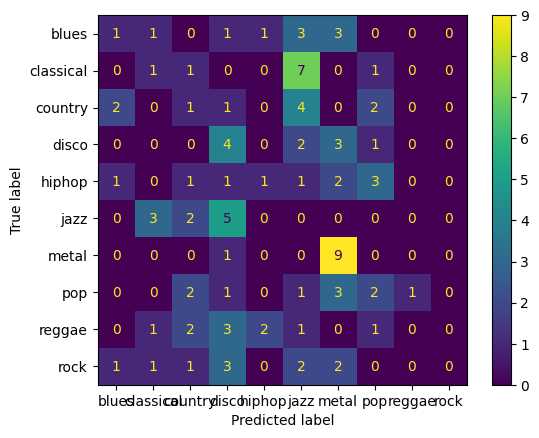

In [17]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, ConfusionMatrixDisplay, classification_report

# --- 1. Setup and Preprocessing ---
ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
STEMS_PATH = os.path.join(ROOT, 'genres_stems')
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

def extract_features(song_path):
    # Load 10s at 22050Hz
    y, sr = librosa.load(os.path.join(song_path, 'other.wav'), sr=22050, duration=10)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    return [float(tempo), spec_cent, zcr, rolloff]

# --- 2. Data Preparation & Stratified Split ---
data = []
for g in GENRES:
    gp = os.path.join(STEMS_PATH, g)
    songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
    for s in songs[:50]: # Sampling 50 for speed; use all for final
        data.append({'path': os.path.join(gp, s), 'genre': g})

df = pd.DataFrame(data)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['genre'], random_state=42)

# --- 3. Model Training (Decision Tree) ---
X_train = np.array([extract_features(p) for p in train_df['path']])
y_train = train_df['genre']
X_val = np.array([extract_features(p) for p in val_df['path']])
y_val = val_df['genre']

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_val)
macro_f1 = f1_score(y_val, y_pred, average='macro')

print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")
print("Detailed Classification Report:")
print(ConfusionMatrixDisplay.from_predictions(y_val, y_pred))

print(classification_report(y_val, y_pred))